# Financial Market Modeling and Sentiment Analysis

In [1]:
import heapq as hp
import numpy as np
import matplotlib.pyplot as plt

## 1. Market Simulation with Order Book Dynamics

This section implements a basic market simulation using a continuous double auction model with buy and sell order books. It demonstrates fundamental concepts of market micro-structure, including order placement, order matching, and the evolution of equilibrium prices. The simulation uses heap data structures for efficient order book management and visualizes price convergence.

In [2]:
import heapq as hp
import numpy as np
import matplotlib.pyplot as plt


class Person:
  def __init__(self, id, money):
    self.id = id
    self.money = money


class Market:
    def __init__(self, max_price, max_orders):
        # max heap STORES PRICES AS NEGATIVE
        self.buys = []
        # min heap for sells
        self.sells = []
        self.max_price, self.max_orders = abs(int(max_price)), abs(int(max_orders))

    def add_buy(self, price, quantity=1):
        # REMEMBER TO FLIP THE SIGN AGAIN
        hp.heappush(self.buys, (-price, quantity))

    def add_sell(self, price, quantity=1):
        hp.heappush(self.sells, (price, quantity))

    def fill_order(self):
        # no items
        if not self.buys or not self.sells:
            return

        buy_price, buy_qty = self.buys[0]
        sell_price, sell_qty = self.sells[0]

        buy_price = -buy_price  # FLIP SIGN!!

        # NO MATCH
        if buy_price < sell_price:
            return

        # GET THE PRICE AND QUANTITY
        fill_qty = min(buy_qty, sell_qty)
        #print(f"TRADE: {fill_qty} @ ${sell_price}")

        # Pop both top orders
        hp.heappop(self.buys)
        hp.heappop(self.sells)

        # Put back remaining quantity if partial
        if buy_qty > fill_qty:
            hp.heappush(self.buys, ( -buy_price, buy_qty - fill_qty ))
        if sell_qty > fill_qty:
            hp.heappush(self.sells, ( sell_price, sell_qty - fill_qty ))

    def add_order(self, price, quantity, is_buy):
        if is_buy:
            # If new buy price is greater than or equal to the current top sell price,
            # the buyer will effectively buy at the best available sell price.
            if self.sells and price >= self.sells[0][0]:
                self.add_buy(self.sells[0][0], quantity)
            else:
                self.add_buy(price, quantity)
        else: # is_sell
            # If new sell price is less than or equal to the current top buy price,
            # the seller will effectively sell at the best available buy price.
            if self.buys and price <= -self.buys[0][0]:
                self.add_sell(-self.buys[0][0], quantity)
            else:
                self.add_sell(price, quantity)

    def print_market(self):
        if self.buys:
            print(f"Top buy: { -self.buys[0][0] }")
        else:
            print("Top buy: None")

        if self.sells:
            print(f"Top sell: { self.sells[0][0] }")
        else:
            print("Top sell: None")

    def run(self, epochs):
        buys_history = []
        sells_history = []
        for e in range(epochs):
            # Randomly create orders
            b_price, s_price = np.random.randint(1, self.max_price + 1), np.random.randint(1, self.max_price + 1)
            b_qty, s_qty = np.random.randint(1, self.max_orders + 1), np.random.randint(1,self.max_orders + 1)

            self.add_order(b_price, b_qty, True)
            self.add_order(s_price, s_qty, False)
            self.fill_order()

            # Capture current market state for plotting
            buys_history.append(-self.buys[0][0] if self.buys else 0)
            sells_history.append(self.sells[0][0] if self.sells else 0)

        return buys_history, sells_history

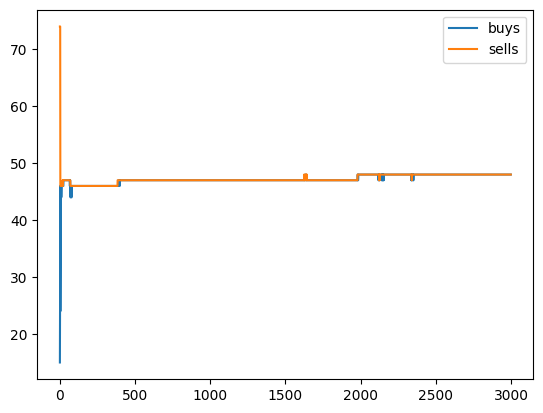

In [3]:
M = Market(100, 100)
buys_data, sells_data = M.run(epochs=3000)
plt.plot(buys_data, label='buys')
plt.plot(sells_data, label='sells')
plt.legend()
plt.show()

In [4]:
import torch.nn as nn
import torch
import torch.nn.functional as F

## 2. Predicting Market Equilibrium with a Neural Network (XGBoost) and Sentiment Analysis

This section explores how external factors, specifically news sentiment, can influence market dynamics. It involves loading and processing real-world financial news and price data, applying a specialized NLP model (FinBERT) for sentiment analysis, and training a machine learning model (XGBoost) to predict market outcomes based on this sentiment.

In [5]:
class Model(nn.Module):
  def __init__(self):
    super(Model, self).__init__()
    self.fc1 = nn.Linear(2, 10)
    self.fc2 = nn.Linear(10, 1)

  def forward(self, x):
    x = self.fc1(x)
    x = F.relu(x)
    x = self.fc2(x)
    return x

In [6]:
model = Model()
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
losses=[]

def find_equilibrum(max_price: int, max_qty: int) -> float:
  m = Market(max_price, max_qty)
  buys_data, sells_data = m.run(epochs=1200)
  return sells_data[-1]

In [ ]:
epochs = 10000 # Reduced epochs for faster execution
max_scale_val = 100.0 # Max possible value for price/quantity for scaling
for e in range(epochs):
  max_price_tensor = torch.randint(1,101, (1,)).float()
  max_qty_tensor = torch.randint(1,101, (1,)).float()

  target = find_equilibrum(max_price_tensor.item(), max_qty_tensor.item())
  scaled_target = target / max_scale_val
  scaled_input = torch.tensor([max_price_tensor/100.0, max_qty_tensor.item()/100.0], dtype=torch.float32)

  pred = model(scaled_input)
  loss = criterion(pred, torch.tensor([scaled_target], dtype=torch.float32))
  losses.append(loss.item())

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if e % 100 == 0:
    print(f"Epoch: {e}, Loss: {loss.item()}")
    print(f"Target: {target}, Prediction: {pred.item()}")

Epoch: 0, Loss: 0.49621254205703735
Target: 51, Prediction: -0.19442357122898102
Epoch: 100, Loss: 0.26678234338760376
Target: 54, Prediction: 0.023490235209465027
Epoch: 200, Loss: 0.011812601238489151
Target: 2, Prediction: 0.12868578732013702
Epoch: 300, Loss: 0.04765131324529648
Target: 41, Prediction: 0.19170819222927094
Epoch: 400, Loss: 0.003932775929570198
Target: 15, Prediction: 0.2127118557691574
Epoch: 500, Loss: 0.006329102907329798
Target: 31, Prediction: 0.23044434189796448
Epoch: 600, Loss: 0.09348274022340775
Target: 56, Prediction: 0.25425052642822266
Epoch: 700, Loss: 0.00984950177371502
Target: 37, Prediction: 0.2707553505897522
Epoch: 800, Loss: 0.030145451426506042
Target: 6, Prediction: 0.23362445831298828
Epoch: 900, Loss: 0.002509231911972165
Target: 21, Prediction: 0.26009222865104675
Epoch: 1000, Loss: 0.027665117755532265
Target: 47, Prediction: 0.303671658039093
Epoch: 1100, Loss: 0.0009516292484477162
Target: 24, Prediction: 0.27084848284721375
Epoch: 1200,

In [ ]:
plt.plot(losses)

In [ ]:
M = Market(33, 43)
buys_data, sells_data = M.run(epochs=10000)
equilibrium = sells_data[-1]

# Prepare scaled input for the model
max_scale_val = 100.0 # Define max_scale_val again for this cell
scaled_input = torch.tensor([33, 43], dtype=torch.float32) / max_scale_val

# Get the model's scaled output and then unscale it
model_output_scaled = model(scaled_input)
model_prediction_unscaled = model_output_scaled.item() * max_scale_val

print(f"Equilibrium: {equilibrium}, Prediction: {model_prediction_unscaled:.2f}")
print(f"{abs(equilibrium - model_prediction_unscaled) / equilibrium * 100:.2f}% error")

plt.plot(buys_data, label='buys')
plt.plot(sells_data, label='sells')
plt.legend()
plt.show()

## 3. Advanced Market Dynamics: Ordinary Differential Equations (ODEs)

This section delves into a more theoretical approach to modeling market behavior using systems of ordinary differential equations (ODEs). It includes an example of a dynamic model involving a moving average, demonstrating complex interactions within a financial system.

In [ ]:
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt
# 30 day moving avg is a queue
y0 = [100,1]
mu_y = np.full(30, y0[0], dtype=float)
eps_surprise = .1

def update_avg(x):
  mu_y[:-1] = mu_y[1:]
  mu_y[-1] = x

def get_avg():
  return mu_y.mean()

def f(t, Y):
    y, yp = Y
    # update the moving average with current y
    update_avg(y)
    mu = get_avg()
    # avoid division-by-zero if y == mu
    if abs(y - mu) < 1e-9:
        return [yp, 0]
    # ODE:
    # y'  = yp
    # yp' = (y - yp) / (y - mu)
    return [yp/(y-mu), (y - yp) / (y - mu)]


In [ ]:
y0 = [5,-2]
solution = sp.integrate.solve_ivp(fun=f, t_span=(0,100), y0=y0, method='RK45', t_eval=np.linspace(0,100,100))
plt.plot(solution.t, solution.y[0])
plt.show()


## 4. Predator-Prey Like Dynamical System for Price and Participants

This section presents a dynamical system inspired by predator-prey models to simulate the interaction between buyers, sellers, and price in a financial market. It allows for exploration of how various parameters, such as influx rates, decay rates, and interaction strength, can influence market stability and price trajectories.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# User inputs (initial conditions)
# -----------------------------
b0 = float(input("Initial buyers (b0): "))
s0 = float(input("Initial sellers (s0): "))
p0 = float(input("Initial price (p0): "))

alpha_b = float(input("Buyer influx / hype (alpha_b): "))
alpha_s = float(input("Seller influx / doom (alpha_s): "))

beta = float(input("Interaction rate (beta): "))
mu_b = float(input("Buyer decay rate (mu_b): "))
mu_s = float(input("Seller decay rate (mu_s): "))

k = float(input("Price sensitivity (k): "))

T = float(input("Total simulation time: "))
dt = float(input("Time step dt: "))

# -----------------------------
# Time grid
# -----------------------------
t = np.arange(0, T, dt)

# -----------------------------
# State variables
# -----------------------------
b = np.zeros_like(t)
s = np.zeros_like(t)
p = np.zeros_like(t)

b[0] = b0
s[0] = s0
p[0] = p0

# -----------------------------
# Simulation (Euler method)
# -----------------------------
for i in range(1, len(t)):
    db = alpha_b - beta * b[i-1] * s[i-1] - mu_b * b[i-1]
    ds = alpha_s - beta * b[i-1] * s[i-1] - mu_s * s[i-1]
    dp = k * (b[i-1] - s[i-1])

    b[i] = max(b[i-1] + db * dt, 0)
    s[i] = max(s[i-1] + ds * dt, 0)
    p[i] = p[i-1] + dp * dt

# -----------------------------
# Plot results
# -----------------------------
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t, b, label="Buyers", color="green")
plt.ylabel("Buyers")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t, s, label="Sellers", color="red")
plt.ylabel("Sellers")
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t, p, label="Price", color="blue")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()

plt.tight_layout()
plt.show()


# 5. Social sentiment for price change prediction
## 5.1 Load in some data
I honestly cant remember where I found this data.

In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/syndicate-data/"
df1 = pd.read_csv(path + "temp_offerings_2021_anon.tsv", sep='\t')
df2 = pd.read_csv(path + "temp_offerings_2022_anon.tsv", sep='\t')
df3 = pd.read_csv(path + "temp_offerings_2023_anon.tsv", sep='\t')
news = pd.concat([df1, df2, df3])

prices = pd.read_csv(path + "temp_prices_2021_2024_anon.tsv", sep='\t')

### 5.2 Data Loading and Preprocessing

Here, financial news headlines and corresponding stock prices are loaded. The data is preprocessed to align news events with subsequent price changes, focusing on news released during market downtime to ensure its influence is reflected in the next trading day's activity.

My first instinct is to measure how positive or negative an article is. By viewing the sentiment associated with a stock, we can predict how it's price will change. Of course, negative sentiment will cause an investment to go down, and positive will cause it to go up.

Sentiment analysis requires a lot of compute power and data, and creating a from-scratch model is beyond the scope of this. I've read about finBERT, which analyzes financial text. finBERT should be perfect for this.

Next, we should clean the data. We want to keep articles with are written during the downtime of the market.

In [ ]:
import datetime as dt

# Ensure timestamp is datetime
news['timestamp'] = pd.to_datetime(news['timestamp'])

# Extract time and weekday
news['time'] = news['timestamp'].dt.time
news['weekday'] = news['timestamp'].dt.weekday  # Monday=0, Sunday=6

# Define market hours
market_open = dt.time(9, 30)
market_close = dt.time(16, 0)

# Market downtime condition
downtime_mask = (
    (news['weekday'] >= 5) |  # Weekend
    (news['time'] < market_open) |  # Before market open
    (news['time'] > market_close)   # After market close
)

# Filter only market downtime news
news_downtime = news[downtime_mask].copy()

In [ ]:
# Ensure 'date' in prices is datetime and sort for correct shifting
prices['date'] = pd.to_datetime(prices['date'])
prices = prices.sort_values(by=['symbol', 'date'])

# Calculate next day's closing price for each symbol
prices['next_day_close'] = prices.groupby('symbol')['close'].shift(-1)

# Calculate daily price change percentage as the target variable
# We'll use the change from today's close to tomorrow's close
prices['price_change'] = (prices['next_day_close'] - prices['close']) / prices['close']

# Create a binary target: 1 if price increased, 0 otherwise
prices['target'] = (prices['price_change'] > 0).astype(int)

# Extract date from news_downtime timestamp for merging
news_downtime['date'] = news_downtime['timestamp'].dt.date

# Convert 'date' column in news_downtime to datetime objects for merging
news_downtime['date'] = pd.to_datetime(news_downtime['date'])

# Merge news sentiment with price data
# We want to link news from a specific day to the price change *after* that day
merged_data = pd.merge(news_downtime, prices, on=['symbol', 'date'], how='inner')

# Display the first few rows of the merged data
print(merged_data.head())
# Display value counts of the target variable to check for class imbalance
print("\nTarget variable distribution:\n", merged_data['target'].value_counts())

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import torch
from torch import sigmoid
from torch import tensor

### 5.3 FinBERT Sentiment Analysis

This sub-section utilizes FinBERT, a BERT-based model fine-tuned for financial sentiment analysis, to quantify the sentiment of news headlines. The sentiment scores are then incorporated as features for predicting price movements.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

pipe = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

In [ ]:
def finbert_score(text):
    result = pipe(text[:512])[0]  # truncated
    label = result["label"]
    score = result["score"]

    if label == "positive":
        return score
    elif label == "negative":
        return -score
    else:
        return 0.0

In [ ]:
merged_data['sentiment'] = merged_data['headline'].apply(finbert_score)

In [ ]:
merged_data['squashed_sentiment'] = merged_data['sentiment'].apply(torch.tensor)
merged_data['squashed_sentiment'] = merged_data['squashed_sentiment'].apply(sigmoid)

In [ ]:
merged_data.sample(3)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import plot_importance

### 5.4 XGBoost Model Training and Evaluation

An XGBoost classifier is trained to predict whether a stock's price will increase or decrease based on the FinBERT sentiment scores. The model's performance is evaluated using accuracy metrics on a held-out test set.

In [ ]:
# Extract the scalar value from each tensor in the 'squashed_sentiment' column
merged_data['squashed_sentiment_scalar'] = merged_data['squashed_sentiment'].apply(lambda x: x.item())

# Now you can use this new column as a feature
X = merged_data[['squashed_sentiment_scalar']]
y = merged_data['target']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

In [ ]:
model = XGBClassifier(objective='binary:logistic', eval_metric='logloss', n_estimators=500, learning_rate=0.01, max_depth=10, random_state=42)

In [ ]:
model.fit(X_train, y_train)
print("XGBoost model training complete.")

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")


In [ ]:
model = XGBClassifier(objective='binary:hinge', eval_metric='logloss', n_estimators=500, learning_rate=0.01, max_depth=10, random_state=42)

In [ ]:
model.fit(X_train, y_train)
print("XGBoost model training complete.")

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")